In [ ]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

In [ ]:
df = pd.read_csv('/content/final.csv')

# convert timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True, errors='coerce')

# sort by time
df = df.sort_values('timestamp').reset_index(drop=True)

df.head()

,timestamp,solar_irradiance,wind_speed,temperature,humidity,atmospheric_pressure,grid_load_demand
0,2023-01-01 00:00:00,0.0,18.770285,18.094905,53.215610,1004.872349,294.401249
1,2023-01-01 01:00:00,0.0,6.638605,11.669042,63.906997,1009.493484,185.824084
2,2023-01-01 02:00:00,0.0,14.296742,12.945826,26.234179,970.753013,347.363574
3,2023-01-01 03:00:00,0.0,22.357572,38.478603,53.165238,970.833286,193.641771
4,2023-01-01 04:00:00,0.0,11.879943,4.807723,69.228330,977.621817,244.023572


In [ ]:
df = df.dropna(subset=['timestamp'])

In [ ]:
print(df['timestamp'].head())
print(df['timestamp'].dtype)

0   2023-01-01 00:00:00
1   2023-01-01 01:00:00
2   2023-01-01 02:00:00
3   2023-01-01 03:00:00
4   2023-01-01 04:00:00
Name: timestamp, dtype: datetime64[ns]
datetime64[ns]


In [ ]:
G = df['solar_irradiance'].values        # W/m^2
V = df['wind_speed'].values              # m/s
Tamb = df['temperature'].values          # °C
Pressure = df['atmospheric_pressure'].values * 100  # convert hPa → Pa
Load = df['grid_load_demand'].values     # kW

In [ ]:
# ---- PV Parameters ----
P_pv_rated = 0.4      # kW per panel
beta = 0.004          # temperature coefficient
NOCT = 45
G_ref = 1000
f_der = 0.85

# ---- Wind Parameters ----
P_wt_rated = 2        # kW per turbine
v_ci = 3
v_r = 12
v_co = 25

# ---- Battery Parameters ----
eta_c = 0.9
eta_d = 0.9
SOC_min = 0.2
SOC_max = 0.9

# ---- Cost Assumptions (example) ----
cost_pv = 250     # $ per panel
cost_wt = 1500    # $ per turbine
cost_bat = 400    # $ per kWh

# ---- Economic Parameters (Only O&M added) ----

interest_rate = 0.05     # discount rate
project_life  = 20       # years

# Wind O&M cost (per turbine per year)
wind_OM_annual = 100     # $/year

# Solar O&M cost (assumed 2% of capital cost)
solar_OM_annual = 0.02 * cost_pv   # = 10 $/year per panel

# Present Worth Factor for annual costs
PW_factor = ((1 + interest_rate)**project_life - 1) / \
            (interest_rate * (1 + interest_rate)**project_life)

In [ ]:
def pv_output(Npv):
    Tcell = Tamb + ((NOCT - 20)/800) * G
    Ppv = Npv * P_pv_rated * (G/G_ref) * (1 - beta*(Tcell - 25))*f_der
    Ppv[Ppv < 0] = 0
    return Ppv

In [ ]:
def wind_output(Nwt):

    Pwt = np.zeros_like(V)

    for i in range(len(V)):
        if V[i] < v_ci or V[i] > v_co:
            Pwt[i] = 0
        elif v_ci <= V[i] < v_r:
            Pwt[i] = P_wt_rated * ((V[i]**3 - v_ci**3)/(v_r**3 - v_ci**3))
        else:
            Pwt[i] = P_wt_rated

    return Nwt * Pwt

In [ ]:
def battery_sim(Ppv, Pwt, Cbat):

    SOC = 0.5
    deficit = 0

    for t in range(len(Load)):

        Pnet = Ppv[t] + Pwt[t] - Load[t]

        if Pnet > 0:  # charge
            SOC += (Pnet * eta_c) / Cbat
        else:         # discharge
            SOC += (Pnet / eta_d) / Cbat

        # limit SOC
        if SOC > SOC_max:
            SOC = SOC_max
        if SOC < SOC_min:
            deficit += abs(Pnet)
            SOC = SOC_min

    return deficit

In [ ]:
def battery_dispatch_profile(Ppv, Pwt, Cbat):

    SOC = 0.5

    battery_discharge = np.zeros(len(Load))
    battery_charge    = np.zeros(len(Load))
    supplied_power    = np.zeros(len(Load))
    deficit_profile   = np.zeros(len(Load))

    for t in range(len(Load)):

        renewable = Ppv[t] + Pwt[t]
        demand = Load[t]

        if renewable >= demand:

            supplied_power[t] = demand
            surplus = renewable - demand

            available_space = (SOC_max - SOC) * Cbat
            charge = min(surplus, available_space)

            battery_charge[t] = charge

            SOC += (charge * eta_c) / Cbat

        else:

            shortage = demand - renewable

            available_energy = (SOC - SOC_min) * Cbat * eta_d

            discharge = min(shortage, max(0, available_energy))

            battery_discharge[t] = discharge

            SOC -= (discharge / eta_d) / Cbat

            supplied_power[t] = renewable + discharge

            deficit_profile[t] = shortage - discharge

        SOC = max(min(SOC, SOC_max), SOC_min)

    return battery_discharge, battery_charge, supplied_power, deficit_profile

In [ ]:
def npc_objective(x):

    Npv, Nwt, Cbat = x

    Npv = int(round(Npv))
    Nwt = int(round(Nwt))

    if Cbat <= 0:
        return 1e10

    Ppv = pv_output(Npv)
    Pwt = wind_output(Nwt)

    _, _, _, deficit_profile = battery_dispatch_profile(Ppv, Pwt, Cbat)
    deficit = np.sum(deficit_profile)

    capital_cost = (Npv * cost_pv +
                    Nwt * cost_wt +
                    Cbat * cost_bat)

    solar_OM_cost = solar_OM_annual * PW_factor * Npv
    wind_OM_cost  = wind_OM_annual  * PW_factor * Nwt

    penalty_cost = 2000 * deficit

    NPC = capital_cost + solar_OM_cost + wind_OM_cost + penalty_cost

    return NPC

In [ ]:
# Decision variables: [Npv, Nwt, Cbat]
lb = np.array([0, 0, 50])       # lower bounds
ub = np.array([2000, 300, 5000])  # upper bounds

dim = 3

In [ ]:
results = {
    'PSO': {},
    'GA': {},
    #'GWO': {},
    'BBBC': {},
    'ABSO': {},
    'IPSO': {}
}

In [ ]:
def run_algorithm(algo_name, algo_function, runs=5):

    print(f"\nRunning {algo_name} for {runs} runs...")

    best_costs = []
    times = []
    curves = []

    best_solution = None
    best_overall_cost = np.inf

    for r in range(runs):

        start = time.time()

        best_pos, best_cost, curve = algo_function(npc_objective, lb, ub, dim)

        end = time.time()

        best_costs.append(best_cost)
        times.append(end - start)
        curves.append(curve)

        if best_cost < best_overall_cost:
            best_overall_cost = best_cost
            best_solution = best_pos

    # average convergence curve
    avg_curve = np.mean(curves, axis=0)

    results[algo_name]['best_npc'] = np.min(best_costs)
    results[algo_name]['mean_npc'] = np.mean(best_costs)
    results[algo_name]['std_npc'] = np.std(best_costs)
    results[algo_name]['time'] = np.mean(times)
    results[algo_name]['curve'] = avg_curve
    results[algo_name]['best_solution'] = best_solution

In [ ]:
def PSO(objf, lb, ub, dim, N=30, Max_iter=50):

    w, c1, c2 = 0.7, 2, 2

    X = np.random.uniform(lb, ub, (N, dim))
    V = np.zeros((N, dim))

    pbest = X.copy()
    pbest_val = np.array([objf(x) for x in X])

    gbest = pbest[np.argmin(pbest_val)].copy()
    gbest_val = np.min(pbest_val)

    curve = []

    for t in range(Max_iter):

        for i in range(N):

            r1, r2 = np.random.rand(dim), np.random.rand(dim)

            V[i] = (w*V[i] +
                    c1*r1*(pbest[i]-X[i]) +
                    c2*r2*(gbest-X[i]))

            X[i] += V[i]
            X[i] = np.clip(X[i], lb, ub)

            fitness = objf(X[i])

            if fitness < pbest_val[i]:
                pbest[i] = X[i].copy()
                pbest_val[i] = fitness

        gbest = pbest[np.argmin(pbest_val)].copy()
        gbest_val = np.min(pbest_val)

        curve.append(gbest_val)

    return gbest, gbest_val, curve

In [ ]:
def GA(objf, lb, ub, dim, N=30, Max_iter=50):

    pop = np.random.uniform(lb, ub, (N, dim))
    curve = []

    for gen in range(Max_iter):

        fitness = np.array([objf(ind) for ind in pop])
        idx = np.argsort(fitness)
        pop = pop[idx]

        new_pop = pop[:2].copy()

        while len(new_pop) < N:

            p1, p2 = pop[np.random.randint(0,10)], pop[np.random.randint(0,10)]
            alpha = np.random.rand()
            child = alpha*p1 + (1-alpha)*p2

            if np.random.rand() < 0.1:
                child += np.random.randn(dim)

            child = np.clip(child, lb, ub)
            new_pop = np.vstack((new_pop, child))

        pop = new_pop[:N]
        curve.append(np.min(fitness))

    best = pop[np.argmin([objf(ind) for ind in pop])]
    return best, objf(best), curve

In [ ]:
def GWO(objf, lb, ub, dim, N=30, Max_iter=50):

    X = np.random.uniform(lb, ub, (N, dim))
    curve = []

    for t in range(Max_iter):

        fitness = np.array([objf(x) for x in X])
        idx = np.argsort(fitness)

        alpha, beta, delta = X[idx[0]], X[idx[1]], X[idx[2]]

        a = 2 - t*(2/Max_iter)

        for i in range(N):

            for leader in [alpha, beta, delta]:

                r1, r2 = np.random.rand(dim), np.random.rand(dim)
                A = 2*a*r1 - a
                C = 2*r2

                D = abs(C*leader - X[i])
                X[i] = leader - A*D

            X[i] = np.clip(X[i], lb, ub)

        curve.append(np.min(fitness))

    best = X[np.argmin([objf(x) for x in X])]
    return best, objf(best), curve

In [ ]:
def BBBC(objf, lb, ub, dim, N=30, Max_iter=50):

    X = np.random.uniform(lb, ub, (N, dim))
    curve = []

    for t in range(Max_iter):

        fitness = np.array([objf(x) for x in X])
        center = np.sum(X/fitness.reshape(-1,1), axis=0) / np.sum(1/fitness)

        X = center + np.random.randn(N, dim)*(ub-lb)/(t+1)
        X = np.clip(X, lb, ub)

        curve.append(np.min(fitness))

    best = X[np.argmin([objf(x) for x in X])]
    return best, objf(best), curve

In [ ]:
def ABSO(objf, lb, ub, dim, N=30, Max_iter=50):

    X = np.random.uniform(lb, ub, (N, dim))
    curve = []

    for t in range(Max_iter):

        fitness = np.array([objf(x) for x in X])
        best = X[np.argmin(fitness)]

        for i in range(N):

            phi = np.random.uniform(-1,1,dim)
            k = np.random.randint(0,N)
            X[i] = X[i] + phi*(X[i]-X[k])

            if objf(X[i]) > objf(best):
                X[i] = best + np.random.randn(dim)

            X[i] = np.clip(X[i], lb, ub)

        curve.append(np.min(fitness))

    best = X[np.argmin([objf(x) for x in X])]
    return best, objf(best), curve

In [ ]:
def IPSO(objf, lb, ub, dim, N=30, Max_iter=50):

    w_max, w_min = 0.9, 0.4
    c1, c2 = 1.5, 1.5

    X = np.random.uniform(lb, ub, (N, dim))
    V = np.zeros((N, dim))

    pbest = X.copy()
    pbest_val = np.array([objf(x) for x in X])

    gbest = pbest[np.argmin(pbest_val)].copy()
    gbest_val = np.min(pbest_val)

    curve = []

    for t in range(Max_iter):

        w = w_max - t*((w_max-w_min)/Max_iter)

        for i in range(N):

            r1, r2 = np.random.rand(dim), np.random.rand(dim)

            V[i] = (w*V[i] +
                    c1*r1*(pbest[i]-X[i]) +
                    c2*r2*(gbest-X[i]))

            X[i] += V[i]
            X[i] = np.clip(X[i], lb, ub)

            fit = objf(X[i])

            if fit < pbest_val[i]:
                pbest[i] = X[i].copy()
                pbest_val[i] = fit

        gbest = pbest[np.argmin(pbest_val)].copy()
        gbest_val = np.min(pbest_val)

        curve.append(gbest_val)

    return gbest, gbest_val, curve

In [ ]:
run_algorithm('PSO', PSO)
run_algorithm('GA', GA)
run_algorithm('GWO', GWO)
run_algorithm('BBBC', BBBC)
run_algorithm('ABSO', ABSO)
run_algorithm('IPSO', IPSO)


Running PSO for 5 runs...

Running GA for 5 runs...

Running BBBC for 5 runs...

Running ABSO for 5 runs...

Running IPSO for 5 runs...


In [ ]:
comparison = []

for algo in results:
    comparison.append([
        algo,
        results[algo]['best_npc'],
        results[algo]['mean_npc'],
        results[algo]['std_npc'],
        results[algo]['time']
    ])

comparison_df = pd.DataFrame(
    comparison,
    columns=[
        'Algorithm',
        'Best NPC',
        'Mean NPC',
        'Std Dev',
        'Time (s)'
    ]
)

comparison_df

,Algorithm,Best NPC,Mean NPC,Std Dev,Time (s)
0,PSO,2.352258e+06,2.357181e+06,5192.265984,16.588942
1,GA,2.596435e+06,2.807807e+06,175507.378028,16.783360
2,BBBC,2.580632e+06,2.651168e+06,84024.272484,16.431148
3,ABSO,2.432095e+06,2.583285e+06,122113.326153,49.476210
4,IPSO,2.352253e+06,2.352590e+06,670.363289,16.805065


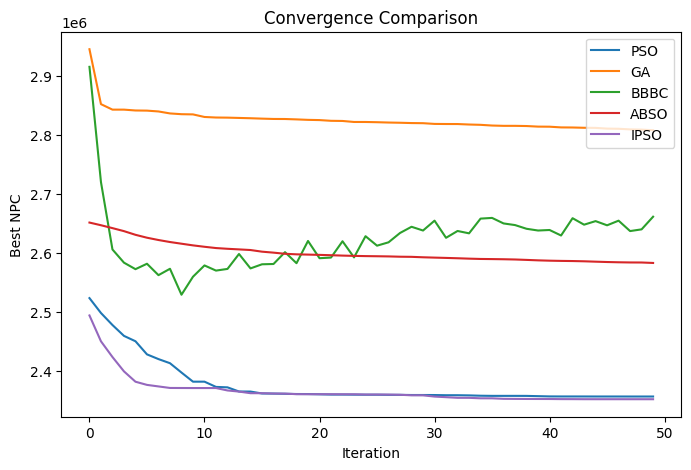

In [ ]:
plt.figure(figsize=(8,5))

for algo in results:
    plt.plot(results[algo]['curve'], label=algo)

plt.xlabel('Iteration')
plt.ylabel('Best NPC')
plt.legend()
plt.title('Convergence Comparison')
plt.show()